In [1]:
print("HI")

HI


## Time Series Visualization for a Sales Dataset

1. Learning Objective

    In this lab, you will:
    - Understand the concept of time series data
    - Load or generate a sales dataset
    - Perform basic preprocessing of time series data
    - Visualize sales trends over time using line plots and moving averages
    - Gain insights about sales patterns (seasonality, trends)


Time series data is a sequence of data points recorded at specific
# time intervals. It is widely used in business analytics, especially 
# for tracking sales, stock prices, weather data, etc.
#
# In this exercise, we focus on visualizing sales data over time.
# Visualization helps us observe:
# - Trends (overall increase/decrease in sales)
# - Seasonality (repeating patterns, e.g., higher sales in December)
# - Anomalies (unexpected spikes or drops)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [6]:
date_range = pd.date_range(start="2022-01-01", end="2023-12-31", freq="D")
np.random.seed(42)
sales = np.random.randint(100, 500, size=len(date_range))

data = pd.DataFrame({"Date": date_range, "Sales": sales})
data.set_index("Date", inplace=True)

print("First 5 rows of dataset:")
print(data.head())

First 5 rows of dataset:
            Sales
Date             
2022-01-01    202
2022-01-02    448
2022-01-03    370
2022-01-04    206
2022-01-05    171


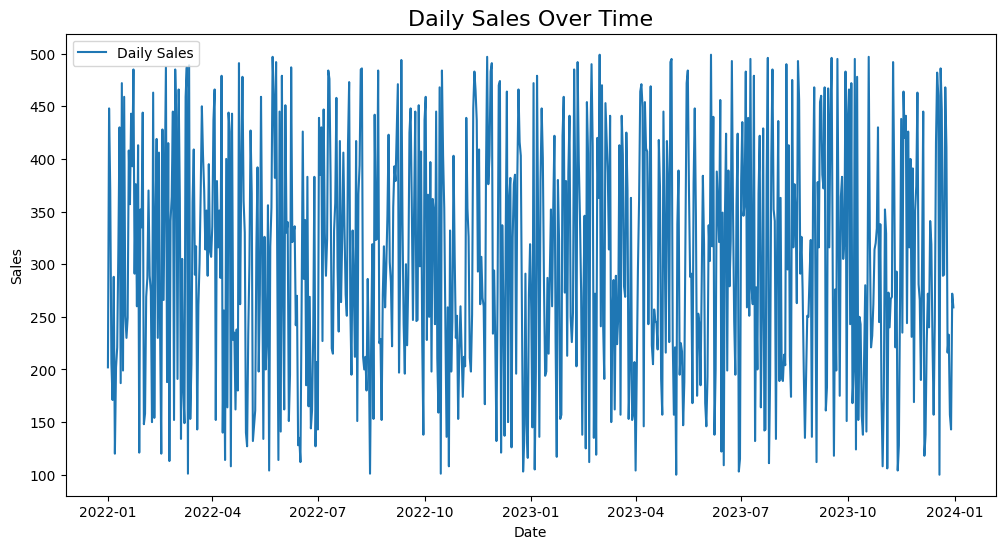

In [9]:
# Basic Visualization

plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Sales"], label="Daily Sales")
plt.title("Daily Sales Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

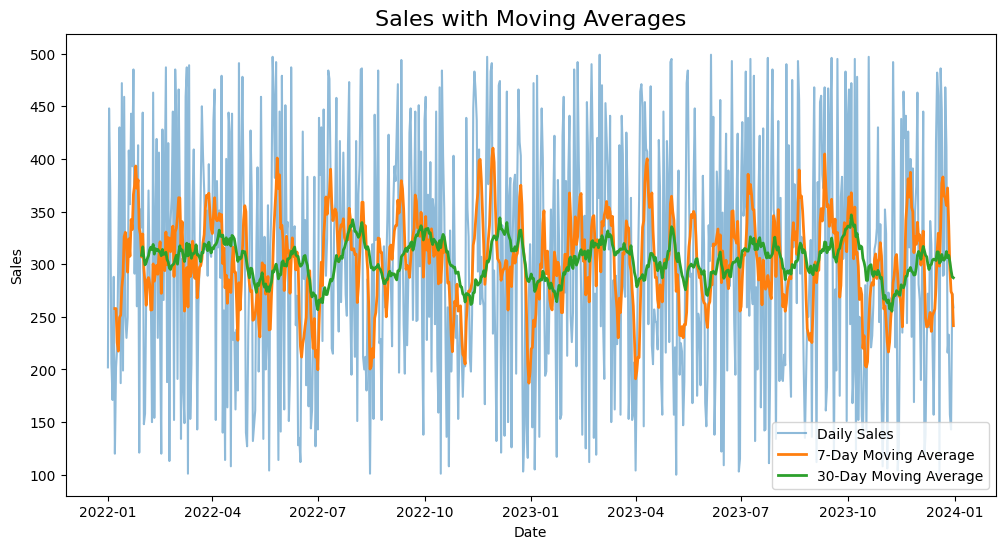

In [12]:
# Moving Average (Trend Smoothing)

data["7-day MA"] = data["Sales"].rolling(window=7).mean()
data["30-day MA"] = data["Sales"].rolling(window=30).mean()

# What happened?

# The rolling average smooths the data.

# Instead of sharp jumps (10 → 20 → 30 → 40 → 50), you now see a smoother line (20 → 30 → 40).


# Example:

# With rolling(window=3).mean()

# This means: Take the last 3 days, and calculate the average.

# Step by step:
# Day 1 → Not enough (need 3 days) → NaN
# Day 2 → Not enough (need 3 days) → NaN
# Day 3 → (10 + 20 + 30) ÷ 3 = 20
# Day 4 → (20 + 30 + 40) ÷ 3 = 30
# Day 5 → (30 + 40 + 50) ÷ 3 = 40

plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Sales"], alpha=0.5, label="Daily Sales")
plt.plot(data.index, data["7-day MA"], label="7-Day Moving Average", linewidth=2)
plt.plot(data.index, data["30-day MA"], label="30-Day Moving Average", linewidth=2)
plt.title("Sales with Moving Averages", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

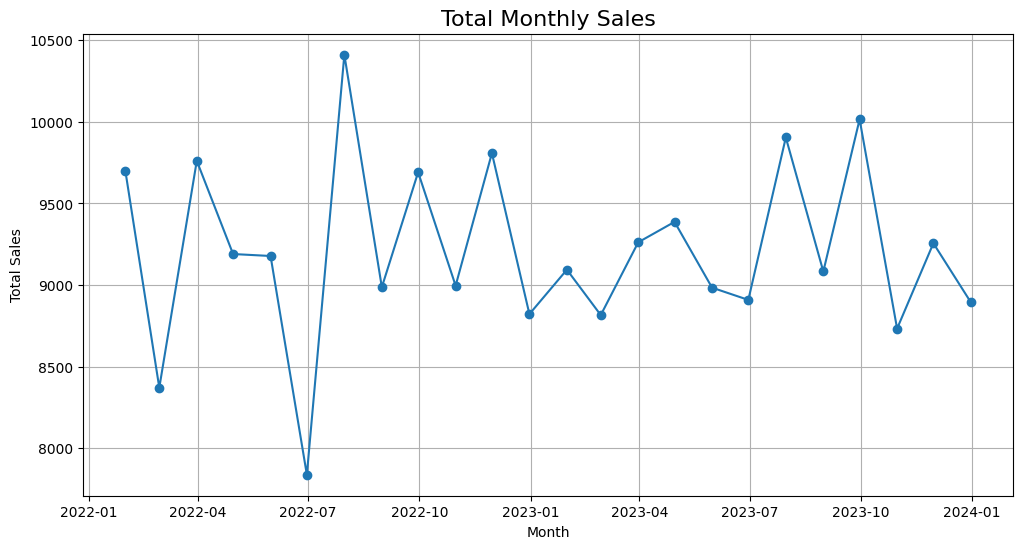

In [11]:
# Monthly Aggregation

monthly_sales = data["Sales"].resample("M").sum()


# What resample("M") does:
# resample() in Pandas is used to change the frequency of time series data.

# "M" means Month-end frequency.
# It groups your daily data by end of each month.

# Example: All dates in January get grouped under 2025-01-31, all dates in February under 2025-02-28, etc.


plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", linestyle="-")
plt.title("Total Monthly Sales", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### From the visualizations:
    - Observe daily fluctuations in sales
    - Identify general trends using moving averages
    - Compare monthly sales performance

# Task To perform

Task 1: Daily vs Weekly vs Monthly Sales

Use the sales dataset.
Plot three lines in one graph:
Daily sales
Weekly total sales (resample("W").sum())
Monthly total sales (resample("M").sum())
Compare how the curves look different.




Task 2: Rolling Average

Compute 7-day and 30-day rolling averages of daily sales.
Plot them along with original daily sales.
Write down your observation:
Which rolling average is smoother? Why?





Task 3: Identify Best Sales Month

Using resample("M"), find the month with the highest total sales.
Print its value.




Task 4: Compare Two Years

If dataset has multiple years:
Resample data monthly.
Plot a bar chart comparing Year 1 vs Year 2 monthly sales.
Answer: Which year performed better overall?




Task 5: Add Your Own Insight

Ask students: “What extra visualization can you make from this dataset that gives new insight?”
Example: Highest sales day of each week, seasonal spikes, etc